# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://portfoliooptimization.org)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__

## Tutorial 23: Hierarchical Risk Parity (HRP) Portfolio Optimization

## 1. Downloading the data:

In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2016-01-01'
end = '2019-12-30'

# Tickers of assets
assets = ['JCI', 'TGT', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'PSA', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SHW', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  25 of 25 completed


In [11]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-2.0257%,0.4057%,0.4036%,1.9692%,0.0180%,0.9305%,0.3678%,0.5783%,0.9483%,-1.1954%,...,1.5881%,0.0212%,2.8236%,0.4043%,0.6987%,1.7539%,-0.1730%,0.2410%,1.3734%,-1.0857%
2016-01-06,-11.4864%,-1.5879%,0.2411%,-1.7557%,-0.7727%,-1.2474%,-0.1736%,-1.1240%,-3.5867%,-0.9551%,...,0.5547%,0.0212%,0.1592%,-2.8931%,0.3108%,-1.0155%,-0.7653%,-3.0048%,-0.9035%,-2.9144%
2016-01-07,-5.1388%,-4.1922%,-1.6573%,-2.7699%,-1.1047%,-1.9769%,-1.2206%,-0.8855%,-4.6058%,-2.5394%,...,-2.2067%,-3.0309%,-1.0410%,-2.7417%,-1.6148%,-0.2700%,-2.2845%,-2.0570%,-0.5492%,-3.0020%
2016-01-08,0.2736%,-2.2705%,-1.6037%,-2.5425%,0.1099%,-0.2241%,0.5706%,-1.6402%,-1.7642%,-0.1649%,...,-0.1538%,-1.1366%,-0.7308%,0.0828%,0.0895%,-3.3838%,-0.1117%,-1.1386%,-0.9720%,-1.1254%
2016-01-11,-4.3383%,0.1692%,-1.6851%,-1.0215%,0.0915%,-1.1791%,0.5674%,0.5287%,0.6617%,0.0330%,...,1.6436%,0.0000%,0.9869%,0.0827%,1.2225%,1.4569%,0.5366%,-0.4607%,0.5800%,-1.9919%


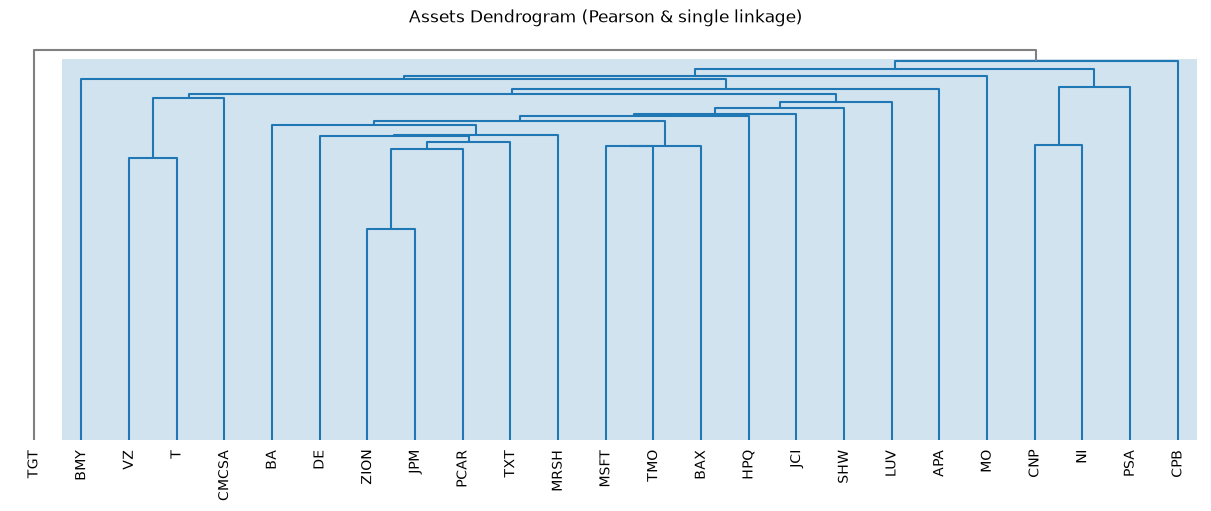

In [12]:
import riskfolio as rp

# Plotting Assets Clusters

ax = rp.plot_dendrogram(returns=Y,
                        codependence='pearson',
                        linkage='single',
                        k=None,
                        max_k=10,
                        leaf_order=True,
                        ax=None)

The dendrogram above suggest that optimal number of clusters are four. However HRP portfolios don't use a number of clusters as input.

## 2. Estimating HRP Portfolio

This is the original model proposed by López de Prado (2016). Riskfolio-Lib expand this model to 32 risk measures.

### 2.1 Calculating the HRP portfolio

In [13]:
# Building the portfolio object
port = rp.HCPortfolio(returns=Y)

# Estimate optimal portfolio:

model='HRP' # Could be HRP or HERC
codependence = 'pearson' # Correlation matrix used to group assets in clusters
rm = 'MV' # Risk measure used, this time will be variance
rf = 0 # Risk free rate
linkage = 'single' # Linkage method used to build clusters
max_k = 10 # Max number of clusters used in two difference gap statistic, only for HERC model
leaf_order = True # Consider optimal order of leafs in dendrogram

w = port.optimization(model=model,
                      codependence=codependence,
                      rm=rm,
                      rf=rf,
                      linkage=linkage,
                      max_k=max_k,
                      leaf_order=leaf_order)

display(w.T)

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
weights,1.7662%,2.4662%,3.4425%,3.3087%,3.6665%,5.5416%,3.5704%,2.7637%,3.1050%,3.5178%,...,5.3445%,3.3185%,6.3523%,3.9585%,6.1093%,3.0446%,3.0600%,2.1024%,7.3486%,1.4838%


### 2.2 Plotting portfolio composition

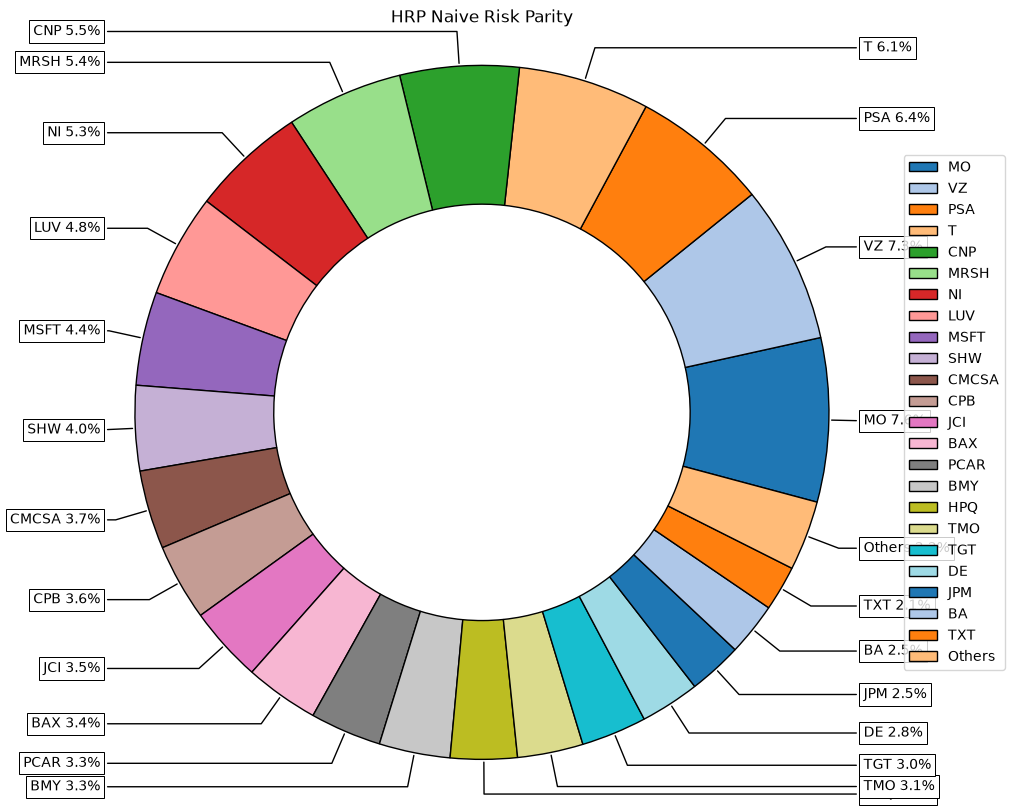

In [14]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w,
                 title='HRP Naive Risk Parity',
                 others=0.05,
                 nrow=25,
                 cmap="tab20",
                 height=8,
                 width=10,
                 ax=None)

### 2.3 Plotting Risk Contribution

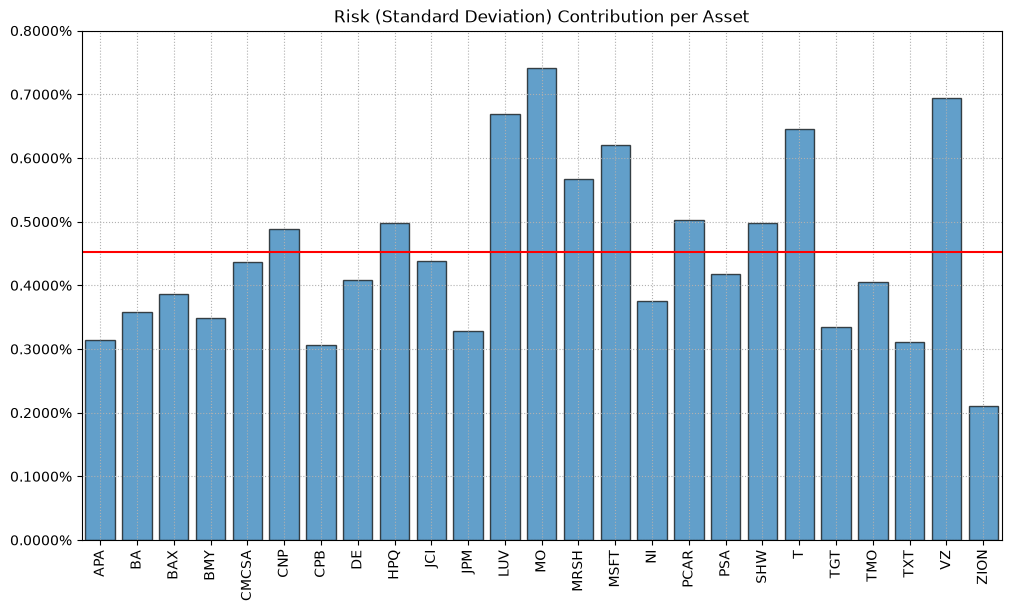

In [15]:
# Plotting the risk contribution per asset

mu = Y.mean()
cov = Y.cov() # Covariance matrix
returns = Y # Returns of the assets

ax = rp.plot_risk_con(
    w=w,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=0,
    alpha=0.05,
    color="tab:blue",
    height=6,
    width=10,
    t_factor=252,
    ax=None)

### 2.4 Calculate Optimal HRP Portfolios for Several Risk Measures

In [16]:
# Risk Measures available:
#
# 'vol': Standard Deviation.
# 'MV': Variance.
# 'MAD': Mean Absolute Deviation.
# 'GMD': Gini Mean Difference.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'VaR': Conditional Value at Risk.
# 'CVaR': Conditional Value at Risk.
# 'TG': Tail Gini.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax).
# 'RG': Range of returns.
# 'CVRG': CVaR Range of returns.
# 'TGRG': Tail Gini Range of returns.
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'DaR': Drawdown at Risk of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.
# 'MDD_Rel': Maximum Drawdown of compounded cumulative returns (Calmar Ratio).
# 'ADD_Rel': Average Drawdown of compounded cumulative returns.
# 'DaR_Rel': Drawdown at Risk of compounded cumulative returns.
# 'CDaR_Rel': Conditional Drawdown at Risk of compounded cumulative returns.
# 'EDaR_Rel': Entropic Drawdown at Risk of compounded cumulative returns.
# 'UCI_Rel': Ulcer Index of compounded cumulative returns.

rms = ['vol', 'MV', 'MAD', 'GMD', 'MSV', 'FLPM', 'SLPM', 'VaR',
       'CVaR', 'TG', 'EVaR', 'WR', 'RG', 'CVRG', 'TGRG', 'MDD', 
       'ADD', 'DaR', 'CDaR', 'EDaR', 'UCI', 'MDD_Rel',
       'ADD_Rel', 'DaR_Rel', 'CDaR_Rel', 'EDaR_Rel', 'UCI_Rel']

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=model,
                          codependence=codependence,
                          rm=i,
                          rf=rf,
                          linkage=linkage,
                          max_k=max_k,
                          leaf_order=leaf_order)

    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms

In [17]:
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

,vol,MV,MAD,GMD,MSV,FLPM,SLPM,VaR,CVaR,TG,EVaR,WR,RG,CVRG,TGRG,MDD,ADD,DaR,CDaR,EDaR,UCI,MDD_Rel,ADD_Rel,DaR_Rel,CDaR_Rel,EDaR_Rel,UCI_Rel
APA,2.43%,1.77%,2.30%,2.35%,2.61%,2.13%,2.52%,2.29%,2.70%,2.86%,3.44%,4.14%,3.02%,2.45%,2.52%,1.15%,0.70%,0.81%,0.92%,1.03%,0.81%,1.39%,0.83%,1.00%,1.12%,1.23%,0.95%
BA,2.87%,2.47%,2.86%,2.85%,2.90%,2.98%,2.97%,2.78%,2.88%,2.96%,3.21%,3.40%,3.17%,2.84%,2.86%,4.82%,4.38%,4.03%,4.45%,4.80%,4.37%,4.68%,4.46%,3.92%,4.36%,4.65%,4.42%
BAX,3.35%,3.44%,3.47%,3.43%,3.18%,3.61%,3.24%,3.17%,3.09%,3.05%,2.73%,2.83%,2.86%,3.25%,3.29%,2.75%,4.84%,3.72%,3.24%,2.96%,4.20%,2.85%,4.87%,3.69%,3.25%,3.01%,4.25%
BMY,3.42%,3.31%,3.37%,3.40%,3.14%,3.22%,3.08%,3.59%,3.26%,3.14%,2.64%,2.29%,3.59%,3.55%,3.52%,2.56%,1.14%,1.65%,1.95%,2.18%,1.37%,2.70%,1.12%,1.67%,2.02%,2.26%,1.36%
CMCSA,3.50%,3.67%,3.40%,3.42%,3.53%,3.45%,3.57%,3.45%,3.66%,3.69%,3.84%,4.12%,4.47%,3.59%,3.59%,4.32%,4.61%,3.59%,3.91%,4.22%,4.41%,4.34%,4.68%,3.64%,4.01%,4.27%,4.48%
CNP,4.37%,5.54%,4.09%,4.18%,4.41%,4.11%,4.46%,4.04%,4.59%,4.73%,5.50%,5.21%,6.38%,4.50%,4.67%,6.54%,6.87%,6.42%,5.99%,6.18%,6.89%,6.33%,6.87%,6.34%,6.06%,6.13%,6.94%
CPB,3.49%,3.57%,3.60%,3.61%,3.69%,3.43%,3.62%,3.98%,3.88%,3.71%,2.89%,2.33%,2.32%,3.56%,3.41%,2.53%,1.17%,1.72%,1.92%,2.14%,1.44%,2.57%,1.23%,1.87%,2.09%,2.27%,1.52%
DE,4.26%,2.76%,4.51%,4.39%,4.35%,4.59%,4.37%,4.28%,4.19%,4.20%,4.48%,4.69%,3.70%,4.16%,4.10%,5.92%,4.39%,4.97%,5.46%,5.60%,4.72%,5.55%,4.26%,4.96%,5.32%,5.42%,4.58%
HPQ,4.54%,3.11%,4.85%,4.76%,4.34%,4.87%,4.33%,4.40%,4.15%,4.02%,3.17%,2.99%,3.07%,4.40%,4.32%,3.53%,3.94%,3.73%,3.54%,3.48%,3.70%,3.73%,3.90%,3.75%,3.57%,3.56%,3.65%
JCI,3.42%,3.52%,3.30%,3.36%,3.43%,3.29%,3.45%,3.31%,3.35%,3.40%,4.86%,6.14%,3.56%,3.39%,3.40%,2.39%,3.10%,3.05%,2.87%,2.69%,3.02%,2.48%,2.92%,3.02%,2.82%,2.71%,2.90%


<Axes: >

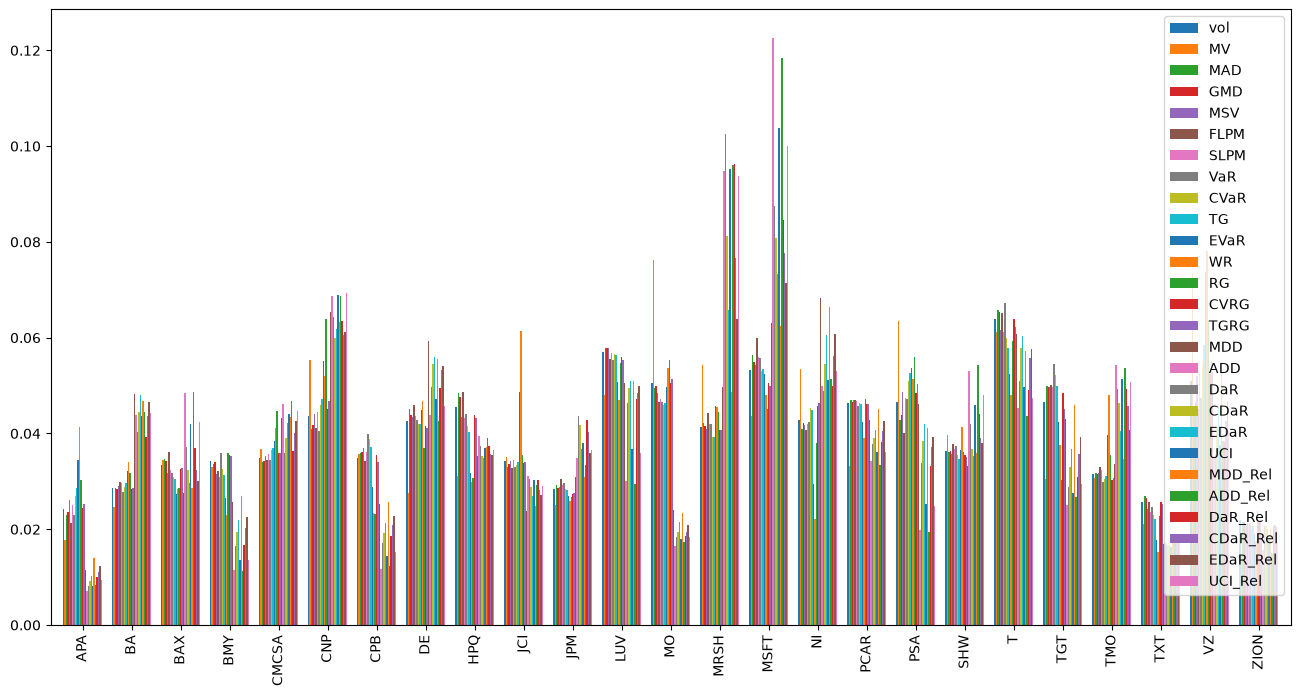

In [18]:
import matplotlib.pyplot as plt

# Plotting a comparison of assets weights for each portfolio

fig = plt.gcf()
fig.set_figwidth(16)
fig.set_figheight(8)
ax = fig.subplots(nrows=1, ncols=1)

w_s.plot(kind='bar', width=0.8, ax=ax)